# Norms, Continuity, Compact Sets, and the Extreme Value Theorem
### MECH 559 - Systems Optimization - L03

This notebook builds the mathematical chain behind **existence of an optimizer**:

$$\text{norm} \rightarrow \text{distance} \rightarrow \text{neighborhood} \rightarrow \text{continuity and set topology} \rightarrow \text{existence of extrema}.$$

## Learning objectives

By the end, you should be able to:

1. Compute and interpret $L_1$, $L_2$, and $L_\infty$ norms.
2. Use norm-induced distance to define open balls and continuity.
3. Distinguish open, closed, bounded, and compact sets.
4. Distinguish a minimum from an infimum and a maximum from a supremum.
5. Apply the Extreme Value Theorem before attempting to solve an optimization problem.

> **Classroom rhythm:** I will pause at each **Predict** prompt, collect answers, then run the next cell.

---
## 1. Import Libraries and Configure Plots

The core notebook requires only NumPy and Matplotlib. `ipywidgets` is optional and is used only in the final classroom-controls section.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"L1": "#D1495B", "L2": "#00798C", "Linf": "#EDAE49"}


def finish_axes(ax, title, xlabel="$x_1$", ylabel="$x_2$"):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect("equal", adjustable="box")
    ax.axhline(0, color="0.25", lw=0.7)
    ax.axvline(0, color="0.25", lw=0.7)


print(f"NumPy {np.__version__}; optional widgets available: {WIDGETS_AVAILABLE}")

NumPy 2.5.0; optional widgets available: True


---
## 2. Compute Common Vector Norms

For $x=(x_1,\ldots,x_n)\in\mathbb{R}^n$,

$$\|x\|_1=\sum_i |x_i|,\qquad \|x\|_2=\sqrt{\sum_i x_i^2},\qquad \|x\|_\infty=\max_i |x_i|.$$

Every norm satisfies positivity, absolute homogeneity, and the triangle inequality.

> **Predict:** For $x=(3,-4,2)$, rank the three norms before running the cell.

## 3. Visualize Norm Balls in Two Dimensions

The closed unit ball is $B_p[0,1]=\{x:\|x\|_p\leq1\}$. Its geometry depends on the norm, even though all norms induce the same open/closed sets in finite-dimensional $\mathbb{R}^n$.

## 4. Compare Distances Induced by Different Norms

A norm induces a metric $d_p(x,y)=\|x-y\|_p$. Different metrics report different distances and different shortest-path geometries.

L1  : explicit = 9.0000, NumPy = 9.0000
L2  : explicit = 5.3852, NumPy = 5.3852
Linf: explicit = 4.0000, NumPy = 4.0000


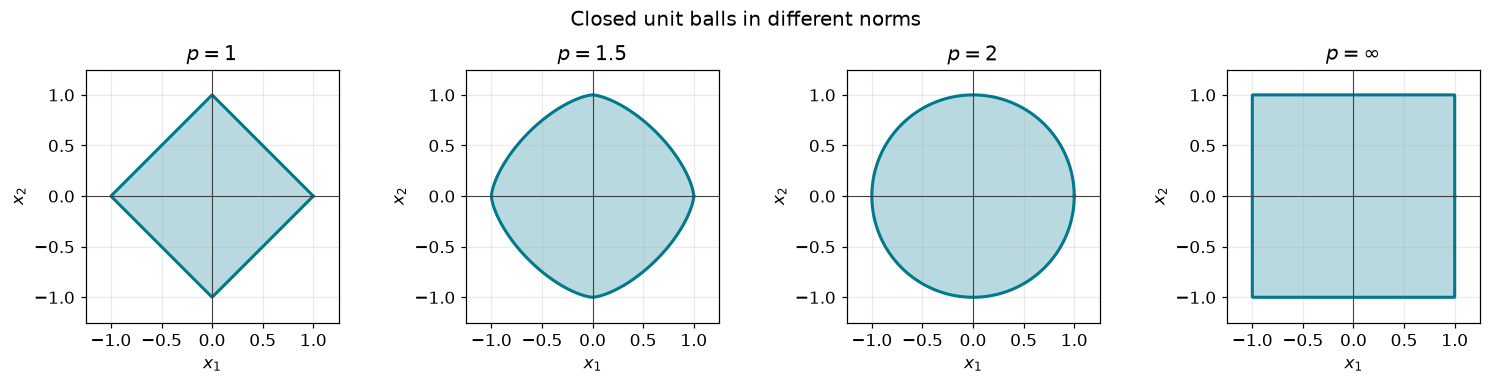


Distances from A to B:
  d_1(A,B) = 2.900
  d_2(A,B) = 2.081
  d_inf(A,B) = 1.700


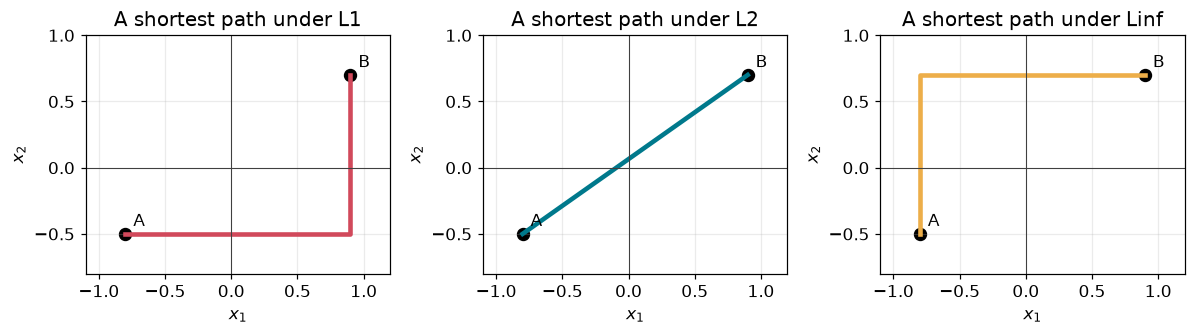

Note: shortest paths need not be unique for L1 or Linfinity.


In [11]:
x = np.array([3.0, -4.0, 2.0])
y = np.array([-1.0, 2.0, 5.0])
alpha = -2.5
orders = {"L1": 1, "L2": 2, "Linf": np.inf}

for name, order in orders.items():
    explicit = {
        "L1": np.sum(np.abs(x)),
        "L2": np.sqrt(np.sum(x**2)),
        "Linf": np.max(np.abs(x)),
    }[name]
    computed = np.linalg.norm(x, ord=order)
    print(f"{name:4s}: explicit = {explicit:.4f}, NumPy = {computed:.4f}")
    assert np.isclose(explicit, computed)
    assert computed >= 0
    assert np.isclose(np.linalg.norm(alpha * x, ord=order), abs(alpha) * computed)
    assert np.linalg.norm(x + y, ord=order) <= computed + np.linalg.norm(y, ord=order) + 1e-12

# Unit balls for p = 1, 2, infinity, and selected intermediate p values.
theta = np.linspace(0, 2 * np.pi, 1000)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, p in zip(axes, [1, 1.5, 2, np.inf]):
    if np.isinf(p):
        boundary = np.vstack((
            np.maximum(np.abs(np.cos(theta)), np.abs(np.sin(theta))) ** -1 * np.cos(theta),
            np.maximum(np.abs(np.cos(theta)), np.abs(np.sin(theta))) ** -1 * np.sin(theta),
        ))
        label = r"$p=\infty$"
    else:
        radius = (np.abs(np.cos(theta))**p + np.abs(np.sin(theta))**p) ** (-1 / p)
        boundary = np.vstack((radius * np.cos(theta), radius * np.sin(theta)))
        label = f"$p={p}$"
    ax.fill(boundary[0], boundary[1], alpha=0.28, color="#00798C")
    ax.plot(boundary[0], boundary[1], color="#00798C", lw=2)
    ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
    finish_axes(ax, label)
plt.suptitle("Closed unit balls in different norms")
plt.tight_layout()
plt.show()

# Distances and representative shortest paths from A to B.
A, B = np.array([-0.8, -0.5]), np.array([0.9, 0.7])
print("\nDistances from A to B:")
for name, order in orders.items():
    print(f"  d_{name[1:]}(A,B) = {np.linalg.norm(B - A, ord=order):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
paths = [
    np.array([A, [B[0], A[1]], B]),
    np.linspace(A, B, 100),
    np.array([A, [A[0], B[1]], B]),
]
for ax, (name, _), path in zip(axes, orders.items(), paths):
    ax.plot(path[:, 0], path[:, 1], lw=3, color=COLORS[name])
    ax.scatter(*A, s=60, color="black"); ax.scatter(*B, s=60, color="black")
    ax.text(*(A + 0.06), "A"); ax.text(*(B + 0.06), "B")
    ax.set_xlim(-1.1, 1.2); ax.set_ylim(-0.8, 1.0)
    finish_axes(ax, f"A shortest path under {name}")
plt.tight_layout(); plt.show()
print("Note: shortest paths need not be unique for L1 or Linfinity.")

---
## 5. Explore Continuous and Discontinuous Functions

A function $f:D\to\mathbb{R}$ is continuous at $x_0\in D$ when

$$\forall\varepsilon>0,\ \exists\delta>0:\ |x-x_0|<\delta\ \Longrightarrow\ |f(x)-f(x_0)|<\varepsilon.$$

Polynomials and $|x|$ are continuous on $\mathbb{R}$. A rational function is continuous wherever its denominator is nonzero. Piecewise definitions may create removable or jump discontinuities.

> **Predict:** Which plotted functions can be repaired at one point, and which cannot?

## 6. Numerically Test the Epsilon-Delta Condition

For $f(x)=x^2$ at $x_0=1$, choosing $\delta=\min(1,\varepsilon/3)$ works because $|x+1|<3$ whenever $|x-1|<1$. A finite numerical test supports an argument but does **not** replace the proof.

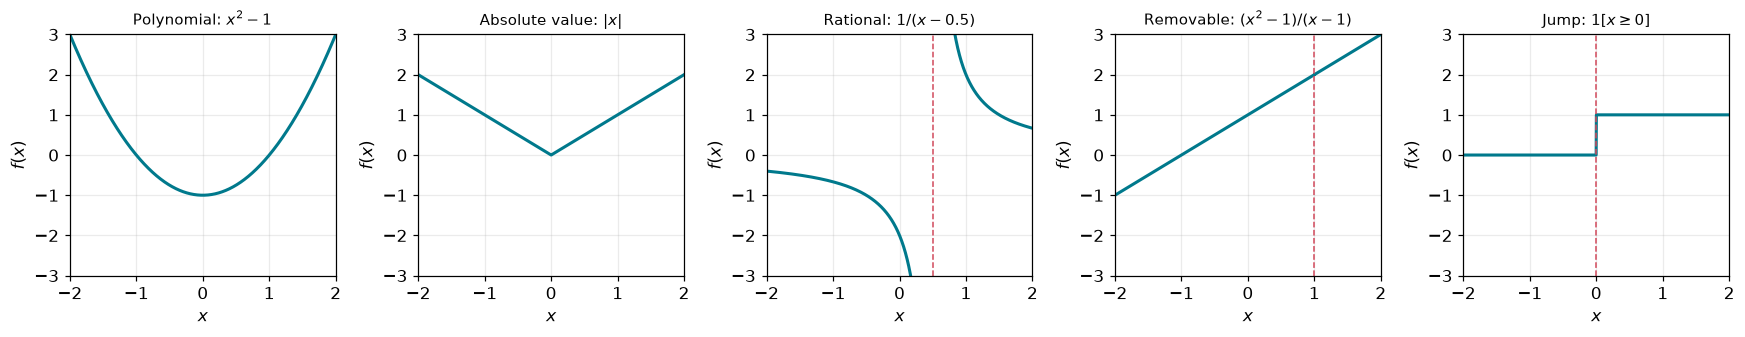

Approaching 0 from the left:  [0. 0. 0. 0. 0. 0. 0. 0.]
Approaching 0 from the right: [1. 1. 1. 1. 1. 1. 1. 1.]
epsilon=0.350, chosen delta=0.117, max sampled output error=0.247


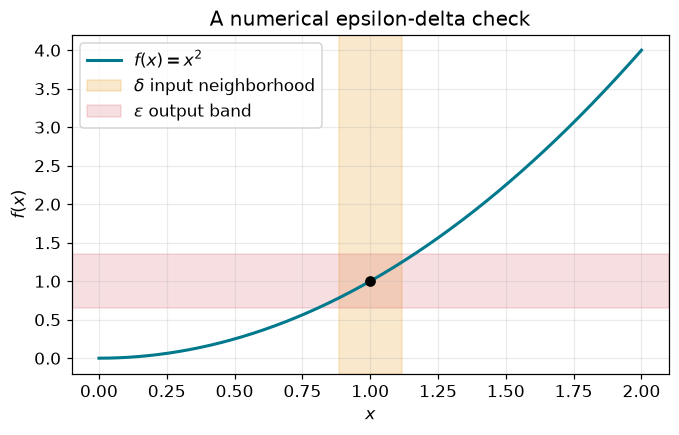

In [12]:
xx = np.linspace(-2, 2, 1200)
functions = [
    ("Polynomial: $x^2-1$", xx**2 - 1, None),
    ("Absolute value: $|x|$", np.abs(xx), None),
    ("Rational: $1/(x-0.5)$", np.where(np.abs(xx - 0.5) > 0.01, 1 / (xx - 0.5), np.nan), 0.5),
    ("Removable: $(x^2-1)/(x-1)$", np.where(np.abs(xx - 1) > 0.01, (xx**2 - 1) / (xx - 1), np.nan), 1.0),
    (r"Jump: $1[x\geq0]$", (xx >= 0).astype(float), 0.0),
]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
for ax, (title, values, marker) in zip(axes, functions):
    ax.plot(xx, values, color="#00798C", lw=2)
    if marker is not None:
        ax.axvline(marker, color="#D1495B", ls="--", lw=1)
    ax.set_title(title, fontsize=10); ax.set_xlim(-2, 2); ax.set_ylim(-3, 3)
    ax.set_xlabel("$x$"); ax.set_ylabel("$f(x)$")
plt.tight_layout(); plt.show()

# Sequence test at the jump: both sequences approach zero, outputs do not agree.
n = np.arange(1, 9)
left_x, right_x = -1 / n, 1 / n
step = lambda z: (np.asarray(z) >= 0).astype(float)
print("Approaching 0 from the left: ", step(left_x))
print("Approaching 0 from the right:", step(right_x))

# Epsilon-delta illustration for f(x)=x^2 at x0=1.
epsilon = 0.35                 # Change this in class.
x0 = 1.0
delta = min(1.0, epsilon / 3)
samples = np.linspace(x0 - 0.999 * delta, x0 + 0.999 * delta, 2001)
errors = np.abs(samples**2 - x0**2)
assert np.all(errors < epsilon)
print(f"epsilon={epsilon:.3f}, chosen delta={delta:.3f}, max sampled output error={errors.max():.3f}")

plot_x = np.linspace(0, 2, 600)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(plot_x, plot_x**2, lw=2, color="#00798C", label="$f(x)=x^2$")
ax.axvspan(x0 - delta, x0 + delta, color="#EDAE49", alpha=0.28, label=r"$\delta$ input neighborhood")
ax.axhspan(x0**2 - epsilon, x0**2 + epsilon, color="#D1495B", alpha=0.18, label=r"$\varepsilon$ output band")
ax.scatter([x0], [x0**2], color="black", zorder=3)
ax.set(xlabel="$x$", ylabel="$f(x)$", title="A numerical epsilon-delta check")
ax.legend(); plt.show()

---
## 7. Represent Open and Closed Sets

- $S$ is **open** if every $x\in S$ has an open ball entirely contained in $S$.
- $S$ is **closed** if it contains all its limit points; equivalently, its complement is open.
- A set can be both open and closed (for example, $\varnothing$ and $\mathbb{R}^n$) or neither (for example, $[0,1)$).

Open balls use $\|x-c\|<r$; closed balls use $\|x-c\|\leq r$.

## 8. Visualize Interior, Boundary, and Closure

- $\operatorname{int}(S)$ contains points with a neighborhood inside $S$.
- $\partial S$ contains points whose every neighborhood meets both $S$ and its complement.
- $\overline S=S\cup\partial S$ is the closure.

For $S=(0,1)$: $\operatorname{int}(S)=(0,1)$, $\partial S=\{0,1\}$, and $\overline S=[0,1]$.

## 9. Illustrate Bounded and Compact Sets

A set is bounded when it lies inside some finite-radius ball.

> **Heine-Borel theorem:** A subset of finite-dimensional Euclidean space $\mathbb{R}^n$ is compact if and only if it is closed and bounded.

This equivalence is context-specific: in general metric or infinite-dimensional normed spaces, closed and bounded need not imply compact.

| Set | Open? | Closed? | Bounded? | Compact in $\mathbb{R}$? |
|---|---:|---:|---:|---:|
| $(0,1)$ | yes | no | yes | no |
| $[0,1]$ | no | yes | yes | yes |
| $[0,1)$ | no | no | yes | no |
| $\mathbb{R}$ | yes | yes | no | no |
| $[0,\infty)$ | no | yes | no | no |

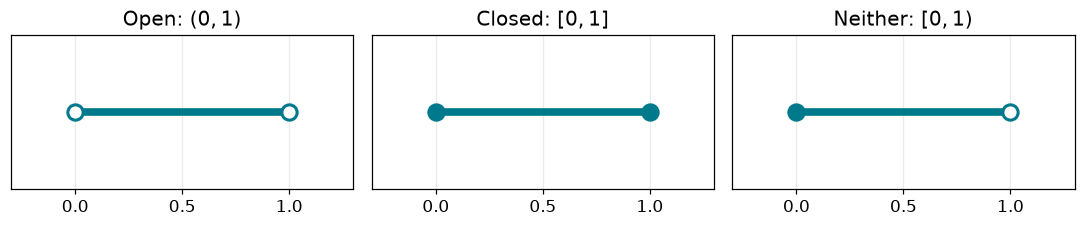

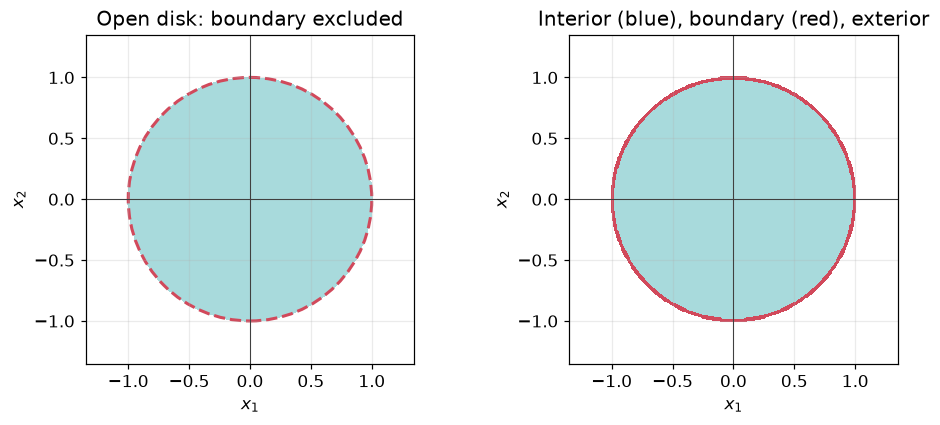

Every tested ball around (1,0) meets both the disk and its complement.


In [13]:
def in_interval(x, left, right, left_closed=True, right_closed=True):
    x = np.asarray(x)
    left_ok = x >= left if left_closed else x > left
    right_ok = x <= right if right_closed else x < right
    return left_ok & right_ok


def plot_interval(ax, left, right, left_closed, right_closed, title):
    ax.plot([left, right], [0, 0], lw=5, color="#00798C")
    for endpoint, closed in [(left, left_closed), (right, right_closed)]:
        ax.scatter(endpoint, 0, s=100, facecolor="#00798C" if closed else "white",
                   edgecolor="#00798C", linewidth=2, zorder=3)
    ax.set(xlim=(left - 0.3, right + 0.3), ylim=(-0.3, 0.3), yticks=[], title=title)

fig, axes = plt.subplots(1, 3, figsize=(10, 2.2))
plot_interval(axes[0], 0, 1, False, False, "Open: $(0,1)$")
plot_interval(axes[1], 0, 1, True, True, "Closed: $[0,1]$")
plot_interval(axes[2], 0, 1, True, False, "Neither: $[0,1)$")
plt.tight_layout(); plt.show()

# Open/closed disks and a sampled interior-boundary-exterior classification.
grid = np.linspace(-1.4, 1.4, 301)
X, Y = np.meshgrid(grid, grid)
R = np.sqrt(X**2 + Y**2)
tol = 0.015
categories = np.where(R < 1 - tol, 0, np.where(np.abs(R - 1) <= tol, 1, 2))
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].contourf(X, Y, R < 1, levels=[-0.5, 0.5, 1.5], colors=["white", "#A8DADC"])
axes[0].add_patch(Circle((0, 0), 1, fill=False, ls="--", lw=2, color="#D1495B"))
finish_axes(axes[0], "Open disk: boundary excluded")
axes[1].contourf(X, Y, categories, levels=[-0.5, 0.5, 1.5, 2.5], colors=["#A8DADC", "#D1495B", "white"])
finish_axes(axes[1], "Interior (blue), boundary (red), exterior")
for ax in axes:
    ax.set_xlim(-1.35, 1.35); ax.set_ylim(-1.35, 1.35)
plt.tight_layout(); plt.show()

# A boundary-point ball always reaches both sides of the disk boundary.
boundary_point = np.array([1.0, 0.0])
for radius in [0.5, 0.1, 0.01]:
    inside = np.linalg.norm(boundary_point - np.array([radius / 2, 0])) < 1
    outside = np.linalg.norm(boundary_point + np.array([radius / 2, 0])) > 1
    assert inside and outside
print("Every tested ball around (1,0) meets both the disk and its complement.")

---
## 10. Demonstrate the Extreme Value Theorem

### Minimum versus infimum

A **minimum** is a value $f(x^*)$ attained at a feasible point. The **infimum** is the greatest lower bound and need not be attained. Maximum and supremum are analogous.

### Extreme Value Theorem (Weierstrass)

> If $D\subset\mathbb{R}^n$ is nonempty and compact and $f:D\to\mathbb{R}$ is continuous, then $f$ attains both a global minimum and a global maximum on $D$.

The theorem gives a **sufficient existence guarantee**, not a necessary condition: some noncompact problems still have optimizers.

> **Predict:** For each example below, decide whether the infimum and supremum are attained before running the code.

| Removed hypothesis | Counterexample | What fails? |
|---|---|---|
| Closedness | $f(x)=x$ on $(0,1)$ | infimum $0$ and supremum $1$ are not attained |
| Boundedness | $f(x)=e^{-x^2}$ on closed $\mathbb{R}$ | infimum $0$ is not attained |
| Continuity | $f(0)=1$, $f(x)=x$ for $x\in(0,1]$ on $[0,1]$ | infimum $0$ is not attained |

The compact-domain example $f(x)=(x-0.35)^2+0.2$ on $[0,1]$ attains both extrema. On the open domain $(0,1)$ this particular function still attains its minimum, illustrating that the theorem is sufficient rather than necessary.

[0,1]: min=0.200 at x=0.350; max=0.623 at x=1.000
(0,1), f(x)=x: inf=0 and sup=1; neither is attained.
R, exp(-x^2): max=1 is attained at 0; inf=0 is not attained.


<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
C:\Users\ahbay\AppData\Local\Temp\ipykernel_3580\2242392947.py:25: SyntaxWarning: invalid escape sequence '\m'
  axes[2].set_title("$e^{-x^2}$ on closed, unbounded $\mathbb{R}$")


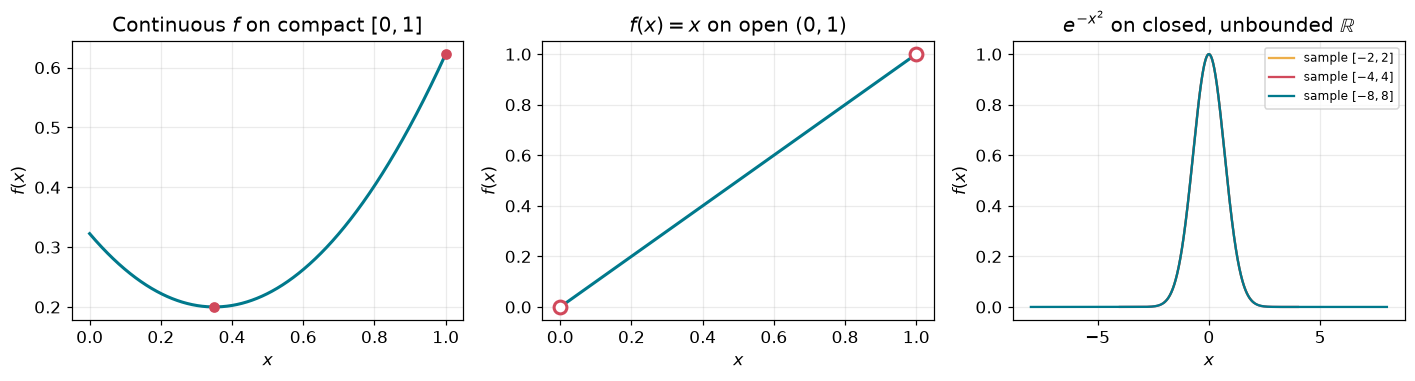

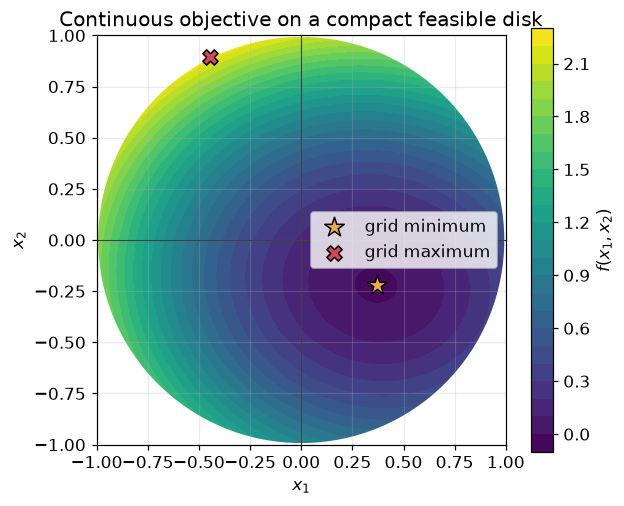

2D grid min=-0.0113 at (np.float64(0.3680000000000001), np.float64(-0.21999999999999997))
2D grid max=2.2525 at (np.float64(-0.44399999999999995), np.float64(0.8960000000000001))


In [14]:
f = lambda x: (x - 0.35)**2 + 0.2
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# Compact [0,1]: both extrema are attained.
x_closed = np.linspace(0, 1, 1001)
y_closed = f(x_closed)
i_min, i_max = np.argmin(y_closed), np.argmax(y_closed)
axes[0].plot(x_closed, y_closed, color="#00798C", lw=2)
axes[0].scatter(x_closed[[i_min, i_max]], y_closed[[i_min, i_max]], color="#D1495B", zorder=3)
axes[0].set_title("Continuous $f$ on compact $[0,1]$")
print(f"[0,1]: min={y_closed[i_min]:.3f} at x={x_closed[i_min]:.3f}; "
      f"max={y_closed[i_max]:.3f} at x={x_closed[i_max]:.3f}")

# Open (0,1): x has infimum 0 and supremum 1, neither attained.
x_open = np.linspace(0.001, 0.999, 999)
axes[1].plot(x_open, x_open, color="#00798C", lw=2)
axes[1].scatter([0, 1], [0, 1], facecolor="white", edgecolor="#D1495B", s=70, lw=2, zorder=3)
axes[1].set_title("$f(x)=x$ on open $(0,1)$")
print("(0,1), f(x)=x: inf=0 and sup=1; neither is attained.")

# Closed but unbounded R: exp(-x^2) has max 1, but infimum 0 is approached at infinity.
for bound, color in zip([2, 4, 8], ["#EDAE49", "#D1495B", "#00798C"]):
    x_r = np.linspace(-bound, bound, 2001)
    axes[2].plot(x_r, np.exp(-x_r**2), color=color, label=f"sample $[-{bound},{bound}]$")
axes[2].set_title("$e^{-x^2}$ on closed, unbounded $\mathbb{R}$")
axes[2].legend(fontsize=8)
print("R, exp(-x^2): max=1 is attained at 0; inf=0 is not attained.")

for ax in axes:
    ax.set_xlabel("$x$"); ax.set_ylabel("$f(x)$")
plt.tight_layout(); plt.show()

# Compact 2D feasible disk: continuous objective attains grid min and max.
grid = np.linspace(-1, 1, 501)
X, Y = np.meshgrid(grid, grid)
mask = X**2 + Y**2 <= 1
objective = (X - 0.35)**2 + 1.4 * (Y + 0.2)**2 + 0.15 * X * Y
feasible_values = np.where(mask, objective, np.nan)
flat_min, flat_max = np.nanargmin(feasible_values), np.nanargmax(feasible_values)
min_index = np.unravel_index(flat_min, feasible_values.shape)
max_index = np.unravel_index(flat_max, feasible_values.shape)
min_point = (X[min_index], Y[min_index]); max_point = (X[max_index], Y[max_index])

fig, ax = plt.subplots(figsize=(6, 5))
contours = ax.contourf(X, Y, feasible_values, levels=24, cmap="viridis")
ax.add_patch(Circle((0, 0), 1, fill=False, color="white", lw=2))
ax.scatter(*min_point, marker="*", s=180, color="#EDAE49", edgecolor="black", label="grid minimum")
ax.scatter(*max_point, marker="X", s=100, color="#D1495B", edgecolor="black", label="grid maximum")
finish_axes(ax, "Continuous objective on a compact feasible disk")
ax.legend(); plt.colorbar(contours, ax=ax, label="$f(x_1,x_2)$")
plt.show()
print(f"2D grid min={feasible_values[min_index]:.4f} at {min_point}")
print(f"2D grid max={feasible_values[max_index]:.4f} at {max_point}")
assert np.isfinite(feasible_values[min_index]) and np.isfinite(feasible_values[max_index])

---
## 11. Interactive Classroom Exercises

The controls below are optional. If `ipywidgets` is unavailable, edit the parameters directly in the earlier cells.

Suggested prompts:

1. Change $p$ from $1$ toward $\infty$. Which directions of the norm ball flatten first?
2. Change $\varepsilon$. Does the conservative choice $\delta=\min(1,\varepsilon/3)$ always pass the sampled test?
3. Toggle interval endpoints. Which combinations are open, closed, compact, or neither?
4. Move the unconstrained minimizer of a quadratic outside $[a,b]$. Where does the constrained minimizer move?

In [15]:
def classroom_demo(p=2.0, epsilon=0.3, left=0.0, right=1.0, minimizer=0.35):
    p_value = np.inf if p >= 10 else p
    theta = np.linspace(0, 2 * np.pi, 800)
    if np.isinf(p_value):
        radius = 1 / np.maximum(np.abs(np.cos(theta)), np.abs(np.sin(theta)))
    else:
        radius = (np.abs(np.cos(theta))**p_value + np.abs(np.sin(theta))**p_value) ** (-1 / p_value)

    delta = min(1.0, epsilon / 3)
    x_test = np.linspace(1 - 0.999 * delta, 1 + 0.999 * delta, 1001)
    epsilon_delta_passes = np.all(np.abs(x_test**2 - 1) < epsilon)

    x_domain = np.linspace(left, right, 800)
    y_domain = (x_domain - minimizer)**2
    i_star = np.argmin(y_domain)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
    axes[0].fill(radius * np.cos(theta), radius * np.sin(theta), color="#A8DADC")
    axes[0].plot(radius * np.cos(theta), radius * np.sin(theta), color="#00798C")
    finish_axes(axes[0], f"Unit ball, p={p_value}")
    axes[1].plot(x_domain, y_domain, color="#00798C", lw=2)
    axes[1].scatter(x_domain[i_star], y_domain[i_star], marker="*", s=150, color="#D1495B")
    axes[1].set(title=f"Minimum on [{left:.1f},{right:.1f}]", xlabel="$x$", ylabel="$f(x)$")
    plt.tight_layout(); plt.show()
    print(f"epsilon-delta sampled check: {epsilon_delta_passes}; delta={delta:.3f}")
    print(f"grid minimizer: x={x_domain[i_star]:.3f}")


if WIDGETS_AVAILABLE:
    controls = {
        "p": widgets.FloatSlider(value=2, min=1, max=10, step=0.5, description="p"),
        "epsilon": widgets.FloatLogSlider(value=0.3, base=10, min=-2, max=0, step=0.1, description="epsilon"),
        "left": widgets.FloatSlider(value=0, min=-1, max=0.5, step=0.1, description="a"),
        "right": widgets.FloatSlider(value=1, min=0.5, max=2, step=0.1, description="b"),
        "minimizer": widgets.FloatSlider(value=0.35, min=-1, max=2, step=0.05, description="x unconstrained"),
    }
    display(widgets.interactive(classroom_demo, **controls))
else:
    print("ipywidgets is not installed; running the default classroom demonstration.")
    classroom_demo()

interactive(children=(FloatSlider(value=2.0, description='p', max=10.0, min=1.0, step=0.5), FloatLogSlider(val…

### More live examples: topology and existence

Use these controls as two separate prediction checks:

1. **Set classifier:** toggle endpoints and the disk boundary. Ask whether each set is open, closed, bounded, and compact before revealing the classification.
2. **EVT laboratory:** change the objective and domain. The display separates an estimated infimum/supremum from whether those values are attained.

> Dense sampling illustrates the behavior but does not prove continuity or attainment.

In [16]:
def topology_lab(left_closed=True, right_closed=True, disk_boundary=False):
    interval_name = f"{'[' if left_closed else '('}0, 1{']' if right_closed else ')'}"
    interval_open = not left_closed and not right_closed
    interval_closed = left_closed and right_closed
    interval_compact = interval_closed  # Every displayed interval is bounded in R.
    disk_name = r"$\{x:\|x\|_2\leq1\}$" if disk_boundary else r"$\{x:\|x\|_2<1\}$"

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
    plot_interval(axes[0], 0, 1, left_closed, right_closed, interval_name)
    theta = np.linspace(0, 2 * np.pi, 500)
    axes[1].fill(np.cos(theta), np.sin(theta), color="#A8DADC", alpha=0.7)
    axes[1].plot(np.cos(theta), np.sin(theta), color="#D1495B", lw=2,
                 ls="-" if disk_boundary else "--")
    finish_axes(axes[1], disk_name)
    axes[1].set_xlim(-1.25, 1.25); axes[1].set_ylim(-1.25, 1.25)
    plt.tight_layout(); plt.show()
    print(f"Interval: open={interval_open}, closed={interval_closed}, bounded=True, compact={interval_compact}")
    print(f"Disk:     open={not disk_boundary}, closed={disk_boundary}, bounded=True, compact={disk_boundary}")


def evt_lab(function="quadratic", domain="closed", left=0.0, right=1.0):
    if right <= left:
        print("Choose right > left.")
        return
    formulas = {
        "quadratic": (lambda z: (z - 0.35)**2 + 0.2, True),
        "linear": (lambda z: z, True),
        "jump": (lambda z: np.where(z == left, 1.0, z - left), False),
    }
    objective, continuous = formulas[function]
    endpoint = 0.0 if domain == "closed" else 1e-5 * (right - left)
    x_values = np.linspace(left + endpoint, right - endpoint, 4001)
    y_values = objective(x_values)
    min_index, max_index = np.argmin(y_values), np.argmax(y_values)
    compact = domain == "closed"

    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.plot(x_values, y_values, color="#00798C", lw=2)
    if compact:
        ax.scatter(x_values[[min_index, max_index]], y_values[[min_index, max_index]],
                   color="#D1495B", zorder=3, label="sample extrema")
    else:
        ax.scatter([left, right], objective(np.array([left, right])), facecolor="white",
                   edgecolor="#D1495B", s=70, lw=2, zorder=3, label="excluded endpoints")
    ax.set(xlabel="$x$", ylabel="$f(x)$", title=f"{function} on {domain} domain")
    ax.legend(); plt.show()
    guarantee = continuous and compact
    print(f"continuous={continuous}; compact={compact}; EVT guarantee={guarantee}")
    print(f"sample infimum≈{y_values[min_index]:.5g}; sample supremum≈{y_values[max_index]:.5g}")
    if not guarantee:
        print("No EVT guarantee: inspect whether each bound is actually attained.")


if WIDGETS_AVAILABLE:
    display(widgets.interactive(
        topology_lab,
        left_closed=widgets.Checkbox(value=True, description="include left"),
        right_closed=widgets.Checkbox(value=True, description="include right"),
        disk_boundary=widgets.Checkbox(value=False, description="include disk boundary"),
    ))
    display(widgets.interactive(
        evt_lab,
        function=widgets.Dropdown(options=["quadratic", "linear", "jump"], description="f"),
        domain=widgets.ToggleButtons(options=["closed", "open"], description="domain"),
        left=widgets.FloatSlider(value=0, min=-2, max=0.5, step=0.1, description="left"),
        right=widgets.FloatSlider(value=1, min=0.5, max=3, step=0.1, description="right"),
    ))
else:
    topology_lab()
    evt_lab()

interactive(children=(Checkbox(value=True, description='include left'), Checkbox(value=True, description='incl…

interactive(children=(Dropdown(description='f', options=('quadratic', 'linear', 'jump'), value='quadratic'), T…

---
## Takeaways

1. A norm measures vector size and induces a distance, neighborhoods, and a topology.
2. Continuity means sufficiently close inputs produce sufficiently close outputs.
3. Open sets contain neighborhoods around all their points; closed sets contain their limit points.
4. In $\mathbb{R}^n$, compact is equivalent to closed and bounded.
5. A continuous objective on a nonempty compact feasible set attains global minimum and maximum values.
6. An infimum or supremum can exist without a feasible point attaining it.
7. The Extreme Value Theorem establishes existence; it does not identify the optimizer or guarantee uniqueness.

## Optional exercises

1. Plot unit balls for $p=0.5$. Which norm axiom fails, and how does the geometry reveal it?
2. Prove the epsilon-delta choice used for $x^2$ at $x_0=1$.
3. Classify $S=\{(x_1,x_2):x_1^2+x_2^2<1,\ x_2\geq0\}$ as open, closed, bounded, and compact.
4. Construct a discontinuous function on $[0,1]$ that has neither a minimum nor a maximum.
5. Find a continuous objective on a noncompact domain that still attains both extrema, confirming that the theorem is sufficient but not necessary.